# Title: Heart Disease Prediction

`Author:` [Mian Abdul Basit](https://github.com/mianabdulbasit-tech/Data-Science-And-AI)\
`Date:` 21.July.2026\
`Dataset:` [Heart Disease UCI](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?resource=download)


## Meta Data [About Dataset]

## Context
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### Content
#### Column Descriptions:
* `id` (Unique id for each patient)
* `age` (Age of the patient in years)
* `origin` (place of study)
* `sex` (Male/Female)
* `cp` chest pain type 
   1. typical angina, 
   2. atypical angina, 
   3. non-anginal, 
   4. asymptomatic
* `trestbps` resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* `chol` (serum cholesterol in mg/dl)
* `fbs` (if fasting blood sugar > 120 mg/dl)
* `restecg` (resting electrocardiographic results)
* `-- Values`: [normal, stt abnormality, lv hypertrophy]
* `thalach`: maximum heart rate achieved
* `exang`: exercise-induced angina (True/ False)
* `oldpeak`: ST depression induced by exercise relative to rest
* `slope`: the slope of the peak exercise ST segment
* `ca`: number of major vessels (0-3) colored by fluoroscopy
* `thal`: [normal; fixed defect; reversible defect]
* `num`: the predicted attribute

### Acknowledgements
#### Creators:
* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.

#### Relevant Papers:
* Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
* Web Link
* David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database." Web Link
* Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61. Web Link

#### Citation Request:
The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution. 

**They would be:**

* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

## Aims and Abjective:

We will fill this after doing exploratory Data Analysis (EDA).

### Import the Libraries

Let's start the project by importing all the libraries that we will need in this project.

In [1]:
# import libraries:

# To handle the data
import pandas as pd
import numpy as np

# To visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# for classification task
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble  import RandomForestClassifier, RandomForestRegressor, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
# matrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [2]:
# 1. Load the data form CSV file from pc
df = pd.read_csv('heart_disease_uci.csv')

# print the first rows of the datafame
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Exploratory Data Analysis (EDA)

### Explore the each column

In [3]:
# explore the each datatype of the each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
# the data shape
df.shape

(920, 16)

In [5]:
# Id column
df['id'].min(), df['id'].max()

(1, 920)

In [6]:
# age column
df['age'].min(), df['age'].max()

(28, 77)

In [7]:
# let's summarie the age column
df['age'].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

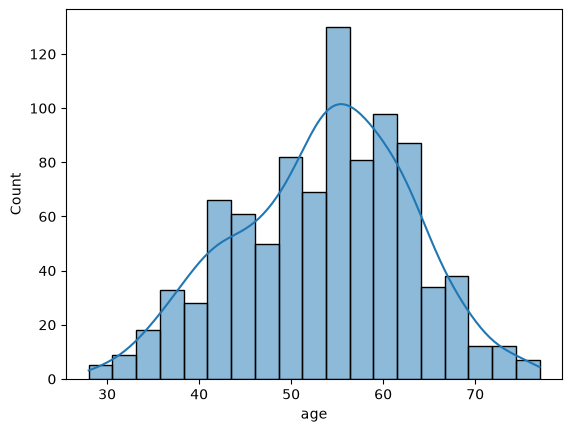

In [8]:
# draw the histogram to see the distribution o the age column
sns.histplot(df['age'], kde=True)

Mean 53.51086956521739
Median 54.0
Mode 54


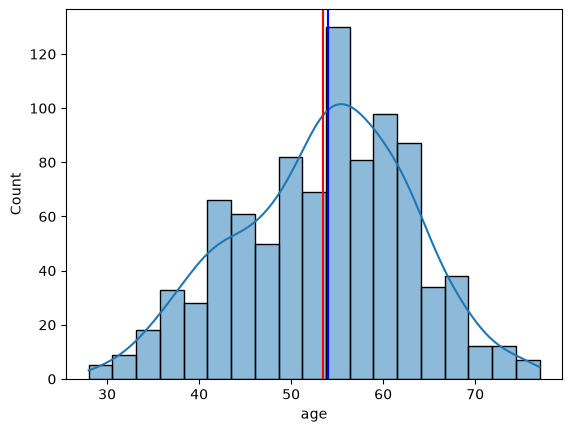

In [9]:
# plot the mean, median, and mode of age column using sns
sns.histplot(df['age'], kde=True)
plt.axvline(df['age'].mean(), color='red')
plt.axvline(df['age'].median(), color='green')
plt.axvline(df['age'].mode()[0], color='blue')

# print the value of mean , median, and mode of the age column
print('Mean', df['age'].mean())
print('Median', df['age'].median())
print('Mode', df['age'].mode()[0])


let's explore the gender based distribution of the dataset for age column.

In [10]:
# plot the histogram of age column using plotly and coloring this by sex.

fig = px.histogram(data_frame=df, x='age', color='sex', )
fig.show()


In [11]:
# find the values of sex column 
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [12]:
# calculate the percentages of male and female value counts in the data
male_count = 726
female_count = 194

total_count = male_count + female_count

# calculate the percentage
male_percentage = (male_count / total_count)*100 
female_percentage = (female_count / total_count)*100 

# desplay the result
print(f"Male percentage in the data: {male_percentage: .2f}%")
print(f"FeMale percentage in the data{female_percentage: .2f}%")

# difference
difference_percentage = ((male_count - female_count) / female_count) * 100

print(f"Male are: {difference_percentage: .2f}% more than females in the data.")

Male percentage in the data:  78.91%
FeMale percentage in the data 21.09%
Male are:  274.23% more than females in the data.


In [13]:
# find the values count of age column grouping by sex column
df.groupby('sex')['age'].value_counts()


sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    71      2
        31      1
        28      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [14]:
# let's deal with dataset column
# find the unique values in dataset column
df['dataset'].unique()

<StringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str

In [15]:
# find unique values count in dataset column
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [16]:
# plot the countplot of the dataset column
#sns.countplot(data=df, x='dataset', hue='sex')

# make a countplot using plotly
fig = px.bar(data_frame=df, x='dataset', color='sex')
fig.show()

# find the values count of datset column grouping by sex column
print(df.groupby('sex')['dataset'].value_counts())


sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64


In [17]:
# make a plot of age column using plotly and coloring by dataset column
fig = px.histogram(data_frame=df, x='age', color='dataset')
fig.show()

# print the value of mean , median, and mode of the age column
print('Mean',df.groupby('dataset')['age'].mean())
print("\nMedian",df.groupby('dataset')['age'].median())
print("\nMode",df.groupby('dataset')['age'].agg(pd.Series.mode))


Mean dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64

Median dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64

Mode dataset
Cleveland              58
Hungary                54
Switzerland            61
VA Long Beach    [62, 63]
Name: age, dtype: object


#### Now Explore cp(Chest Pain) column:

In [18]:
# value count
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

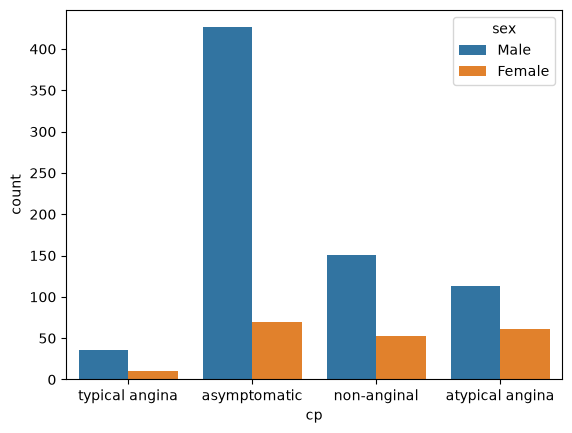

In [19]:
# plot the countplot of the cp column
sns.countplot(data=df, x='cp', hue='sex')

<Axes: xlabel='cp', ylabel='count'>

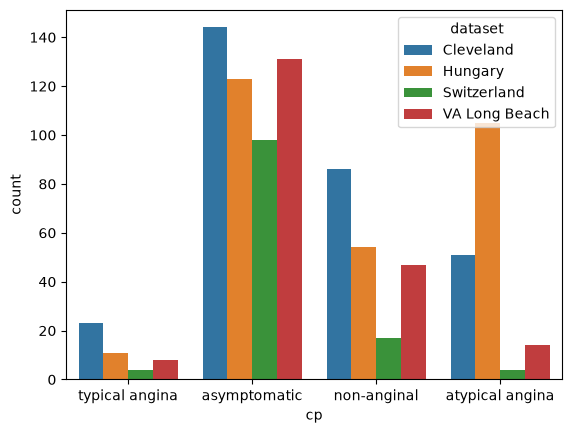

In [20]:
# plot the countplot of the cp column by dataset column
sns.countplot(data=df, x='cp', hue='dataset')

In [21]:
# draw the plot of age column grouped by cp column using plotly
fig = px.histogram(data_frame=df, x='age', color='cp')
fig.show()

#### Let's explore the tresttps (rest blood pressure) column:

The normal resting blood pressure is 120/80 mm Hg. 

`What happen if the blood pressure is high or low.`

In [22]:
# find the value counts of trestbps column
df['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

<Axes: xlabel='trestbps', ylabel='Count'>

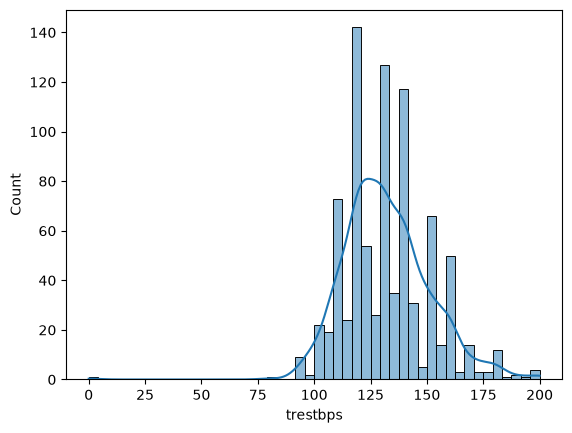

In [23]:
# create a histplot of trestbps column
sns.histplot(df['trestbps'], kde=True)

# Deal with missing values

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [25]:
df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending=False)
missing_data_cols = df.isnull().sum()[df.isnull().sum()>0].index.tolist()
missing_data_cols

['trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

##### let's impute the missing values in the thal column by using ML_models


In [26]:
# define the function to impute the missing values inthal column
def impute_categorical_missing_data(df, target_column):
    """
    Fill missing values in any column using Machine Learning.

    Parameters:
        df : DataFrame
        target_column : Column whose missing values are to be filled

    Returns:
        DataFrame with missing values imputed
    """

    if df is None:
        raise ValueError("DataFrame is None. Please pass a valid DataFrame.")

    df = df.copy()

    # Encode object columns
    encoders = {}

    for col in df.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

    # Separate known and missing rows
    train_data = df[df[target_column].notnull()]
    test_data = df[df[target_column].isnull()]

    # If no missing values
    if len(test_data) == 0:
        print(f"No missing values found in '{target_column}'")
        return df

    # Features
    X_train = train_data.drop(columns=[target_column])
    y_train = train_data[target_column]

    X_test = test_data.drop(columns=[target_column])

    # Select model
    if y_train.dtype == 'object' or y_train.nunique() < 15:
        model = RandomForestClassifier(random_state=42)
    else:
        model = RandomForestRegressor(random_state=42)

    # Train
    model.fit(X_train, y_train)

    # Predict missing values
    predicted_values = model.predict(X_test)

    # Fill missing values
    df.loc[df[target_column].isnull(), target_column] = predicted_values

    return df

In [27]:
# use the function to impute the missing values in each column 

# Impute missing values for each column
for col in missing_data_cols:
    df = impute_categorical_missing_data(df, col)

No missing values found in 'fbs'
No missing values found in 'restecg'
No missing values found in 'exang'
No missing values found in 'slope'
No missing values found in 'thal'


In [28]:
# let's impute the other columns with missing values 
(df.isnull().sum()/ len(df) * 100).sort_values(ascending=False)


id          0.0
age         0.0
sex         0.0
dataset     0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalch      0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
num         0.0
dtype: float64

In [29]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


# Dealing with Outliers

In [32]:
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg', 'fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs',  'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

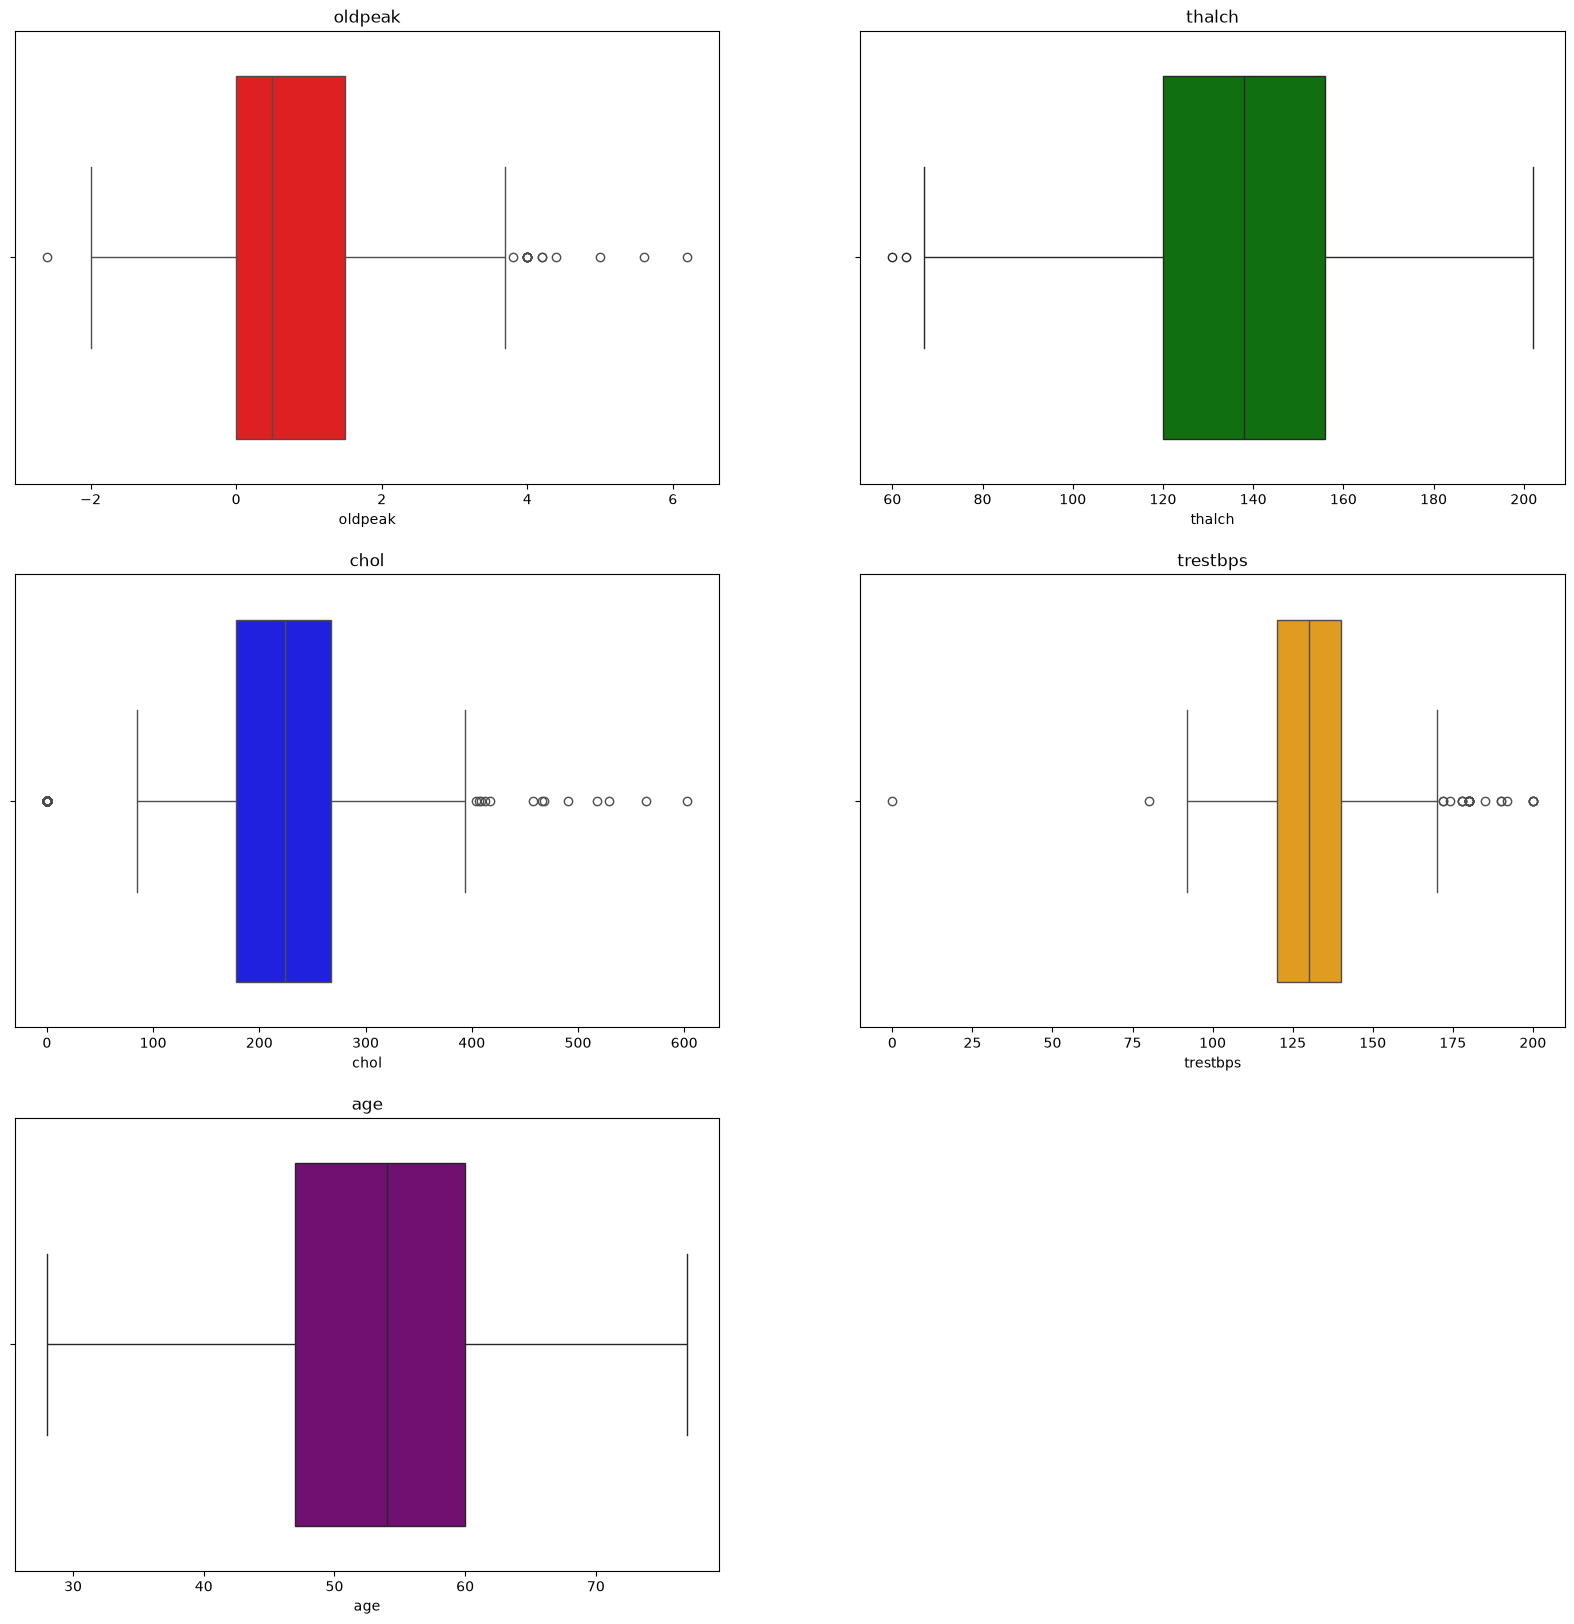

In [34]:
# create boxplot for all numeric columns using for loop and subplot
plt.figure(figsize=(20, 20))

colors = ['red', 'green', 'blue', 'orange', 'purple']

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[col], color=colors[i])
    plt.title(col)

plt.show()

In [40]:
# create the boxplot with plotly

fig = px.box(data_frame=df, y = 'age')
fig.show()

fig = px.box(data_frame=df, y = 'oldpeak')
fig.show()

fig = px.box(data_frame=df, y = 'chol')
fig.show()

fig = px.box(data_frame=df, y = 'thalch')
fig.show()

fig = px.box(data_frame=df, y = 'trestbps')
fig.show()

In [42]:
# print the row from df where trestbps value is 0
df[df['trestbps']==0]

# remove this row from data 
df = df[df['trestbps']!=0]


In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 919 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        919 non-null    int64  
 1   age       919 non-null    int64  
 2   sex       919 non-null    int32  
 3   dataset   919 non-null    int32  
 4   cp        919 non-null    int32  
 5   trestbps  919 non-null    float64
 6   chol      919 non-null    float64
 7   fbs       919 non-null    int32  
 8   restecg   919 non-null    int32  
 9   thalch    919 non-null    float64
 10  exang     919 non-null    int32  
 11  oldpeak   919 non-null    float64
 12  slope     919 non-null    int32  
 13  ca        919 non-null    float64
 14  thal      919 non-null    int32  
 15  num       919 non-null    int64  
dtypes: float64(5), int32(8), int64(3)
memory usage: 93.3 KB


In [44]:
# create boxplot for all numeric columns using for loop and subplot
fig = px.box(data_frame=df, y = 'age')
fig.show()

fig = px.box(data_frame=df, y = 'oldpeak')
fig.show()

fig = px.box(data_frame=df, y = 'chol')
fig.show()

fig = px.box(data_frame=df, y = 'thalch')
fig.show()

fig = px.box(data_frame=df, y = 'trestbps')
fig.show()

<span style='color : yellow; font-size: 350%; font-weight: bold;'>Machine Learning</span>

In [46]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

In [47]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    106
4     28
Name: count, dtype: int64

The columns is `num` which is the predicted attributes. We will use this column to predict the heart disease.
The unique values in this columns are :[0, 1, 2, 3, 4], which states that there are 5 types of heart diseases.
* `0 = No heart disease`
* `1 = mild heart disease`
* `2 = moderate heart disease`
* `3 = severe heart disease`
* `4 = critical heart disease`

In [60]:
# split the data into X and y
X = df.drop('num', axis=1)
y = df['num']

# encode X data using separate label encoder for all categorical columns and save it for inverse transform
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtypes == 'object' or X[col].dtypes == 'categorcal':
        X[col]= label_encoder.fit_transform(X[col])

    else:
        pass

# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Enlist all the models that you will use to predict the heart disease. These models should be  classifiers for multi-class classification
1. logistic Regression
2. KNN
3. NB
4. SVM
5. Decision Tree
6. Random Forest
7. XGBoost
8. GradientBoost
9. AdaBoost


In [62]:
# import all models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# import pipeline
from sklearn.pipeline import Pipeline

# import the metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [67]:
# create a function tp train and evaluate all models and select the best one
# Create a list of models to evaluate
# ==========================================================
# Create Models with Hyperparameters
# ==========================================================

models = {"Random Forest": (RandomForestClassifier(random_state=42),
        {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2"]}),

    "Gradient Boosting": (GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 5],
            "model__subsample": [0.8, 1.0]
        }),

    "Support Vector Machine": (SVC(random_state=42),
        {
            "model__C": [0.1, 1, 10, 100],
            "model__kernel": ["linear", "rbf", "poly"],
            "model__gamma": ["scale", "auto"]
        }),

    "Logistic Regression": (LogisticRegression(random_state=42),
        {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__solver": ["lbfgs", "liblinear"],
            "model__max_iter": [100, 300, 500]
        }
    ),

    "K-Nearest Neighbors": (KNeighborsClassifier(),
        {   "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan", "minkowski"]}),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {   "model__criterion": ["gini", "entropy"],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__splitter": ["best", "random"]}),

    "Ada Boost": (AdaBoostClassifier(random_state=42),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.01, 0.1, 1.0]}),

    "XG Boost": ( XGBClassifier(random_state=42,eval_metric="logloss"),
            {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 5, 7],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]}),

    "Naive Bayes": ( GaussianNB(),{})

}

# best_model = None
# best_accuracy = 0.0

# # Iterate over the models and evaluate their performance
# for name, (model, params) in models.items():
#     # Create a pipeline for each model
#     pipeline = Pipeline([
#         ('scalar', StandardScaler()),
#         ('model', model)
#     ])
    
#     # Perform cross-validation
#     scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
#     # Calculate mean accuracy
#     mean_accuracy = scores.mean()
    
#     # Fit the pipeline on the training data
#     pipeline.fit(X_train, y_train)
    
#     # Make predictions on the test data
#     y_pred = pipeline.predict(X_test)
    
#     # Calculate accuracy score
#     accuracy = accuracy_score(y_test, y_pred)

#     # Print the performance metrics
#     print("Model:", name)
#     print("Cross-validation Accuracy:", mean_accuracy)
#     print("Test Accuracy:", accuracy)
#     print()
    
#     # Check if the current model has the best accuracy
#     if accuracy > best_accuracy:
#         best_accuracy = accuracy
#         best_model = pipeline

# # Retrieve the best model
# print("Best Model:", best_model)

# # save the best model
# import pickle
# pickle.dump(best_model, open('heart_disease_model.pkl', 'wb'))

# ==========================================================
# Function to Select the Best Hyperparameter Tuned Model
# ==========================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

def select_best_classifier(X_train, X_test, y_train, y_test, models):

    best_model = None
    best_model_name = ""
    best_accuracy = 0
    results = []

    # Iterate through every model
    for name, (model, params) in models.items():

        # Create Pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        # Grid Search
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=params,
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )

        # Train
        grid_search.fit(X_train, y_train)

        # Best estimator
        current_model = grid_search.best_estimator_

        # Prediction
        y_pred = current_model.predict(X_test)

        # Accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Save results
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Best Parameters": grid_search.best_params_
        })

        # Save best model
        if accuracy > best_accuracy:

            best_accuracy = accuracy
            best_model = current_model
            best_model_name = name

    # Convert results into DataFrame
    results_df = pd.DataFrame(results)

    # Sort according to accuracy
    results_df = results_df.sort_values(
        by="Accuracy",
        ascending=False
    ).reset_index(drop=True)

    return (
        best_model,
        best_model_name,
        best_accuracy,
        results_df
    )

In [74]:
# Select the Best Classifier

best_model, best_model_name, best_accuracy, results_df = select_best_classifier(
    X_train,
    X_test,
    y_train,
    y_test,
    models
)

# Display Results
print("Best Model :", best_model_name)
print("Best Accuracy :", best_accuracy)

results_df

# Save the Best Model
import pickle
with open("heart_disease_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("\nBest Model Saved Successfully")

# Load Best Model

with open("heart_disease_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model Loaded Successfully")

# Predict using the loaded model
loaded_predictions = loaded_model.predict(X_test)

# Display first 10 predictions
pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": loaded_predictions
}).head(10)


Best Model : Gradient Boosting
Best Accuracy : 0.6739130434782609

Best Model Saved Successfully
Model Loaded Successfully


,Actual,Predicted
0,1,1
1,3,3
2,3,3
3,0,0
4,2,3
5,1,1
6,0,1
7,1,1
8,3,3
9,0,0


#### Outputs:
1. The minimum age to have a heart disease starts from 28 years old.
2. Most of the people get heart heart disease at the age of 53_54 years.
3. Most of the male and female get heart diease t the age 54-55 years.
4. Male percentage in the data:  78.91%
5. FeMale percentage in the data 21.09%
6. Male are:  274.23% more than females in the data.
7. We have the highest number of people from Cleveland (304) and lowest from Switzerland (123).
    1. The highest number of females in this dataset are from Cleveland (97) and lowest from VA Long Beach (6).
    2. The highest number of males in this dataset are from Hungary (212) and lowest from Switzerland (113).